# CLUSTERING

In [2]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClusterMixin
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# Para gráficos en Jupyter
%matplotlib inline

In [3]:
# Cargar datos
path = os.path.join('df_final.csv')
df = pd.read_csv(path)

In [4]:
# Tamaño df
df.shape

(51707, 46)

In [5]:
# Tipo de columnas
print(df.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [6]:
# Visualizar primeras 10 filas
df.head(10)

,booked_at,checkin_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,travel_agency_name,...,Estacion_Estancia,Estacion_Reserva,zona_roja_mes,momento_checkin,total_personas_adult_y_niños,ratio_formularios,reservation_checkin_month_diff,estancia_en_festivo,estancia_en_finde,mes_checkin_numerico
0,2022-11-26 16:10:00,2023-01-01 12:00:00,36,1,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Autumn,0,Antes,1,1.000000,2,0,1,1
1,2022-12-21 17:27:00,2023-01-01 13:09:00,11,9,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Winter,0,Antes,1,1.000000,1,1,1,1
2,2022-09-21 19:46:00,2023-01-01 15:00:00,102,6,January,Sunday,2,4,channel_manager,Booking.com,...,Winter,Autumn,0,Antes,6,0.333333,4,1,1,1
3,2022-09-24 12:09:00,2023-01-01 15:00:00,99,1,January,Sunday,2,2,channel_manager,Booking.com,...,Winter,Autumn,1,Antes,4,0.500000,4,0,1,1
4,2022-10-18 07:12:00,2023-01-01 15:00:00,75,1,January,Sunday,4,0,channel_manager,Booking.com,...,Winter,Autumn,1,Antes,4,1.000000,3,0,1,1
5,2022-11-25 17:50:00,2023-01-01 15:00:00,37,1,January,Sunday,2,1,channel_manager,Booking.com,...,Winter,Autumn,0,NaN,3,0.000000,2,0,1,1
6,2022-11-26 04:10:00,2023-01-01 15:00:00,36,2,January,Sunday,3,0,channel_manager,Booking.com,...,Winter,Autumn,1,NaN,3,0.000000,2,0,1,1
7,2022-12-02 20:02:00,2023-01-01 15:00:00,30,1,January,Sunday,2,2,channel_manager,Booking.com,...,Winter,Winter,0,Antes,4,0.500000,1,0,1,1
8,2022-12-04 23:18:00,2023-01-01 15:00:00,28,2,January,Sunday,1,0,channel_manager,Booking.com,...,Winter,Winter,0,Durante,1,1.000000,1,0,1,1
9,2022-12-11 12:51:00,2023-01-01 15:00:00,21,7,January,Sunday,2,0,channel_manager,Booking.com,...,Winter,Winter,1,NaN,2,0.000000,1,1,1,1


In [7]:
# Columnas:
df.columns

Index(['booked_at', 'checkin_time', 'lead_time', 'lenght_of_stay',
       'checkin_month', 'checkin_day', 'adult_count', 'child_count', 'origin',
       'travel_agency_name', 'requested_category', 'requested_category_name',
       'asset', 'asset_type', 'brand', 'available_units', 'business_segment',
       'rate', 'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'returning_inhabitant', 'recurrence',
       'libere_community', 'bought_products', 'product_count',
       'reservation_net_value', 'total_adr', 'status', 'cancellation_reason',
       'cancellation_lead_time', 'City', 'Reserva_Dia_Semana',
       'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia',
       'Estacion_Reserva', 'zona_roja_mes', 'momento_checkin',
       'total_personas_adult_y_niños', 'ratio_formularios',
       'reservation_checkin_month_diff', 'estancia_en_festivo',
       'estancia_en_finde', 'mes_checkin_numerico'],
      dtype='object')

### SELECCIÓN DE VARIABLES
#### 1. **Variables Cancelacion**: Principalmente se deben excluir aquellas variables que le daran infromacion al modelo que ese cliente vaya a cancelar (Checkin_time, ratio_cancelaciones....).<br>**2. Variables Ctaegoricas** : Convertir a variables dummies <br>3. **Variables Numericas:** Escalar los valores, con min max (Estandar escaler no!)

In [8]:
# funcion para detectar columnas y que si son del tipo yes/no las convierta en 0/1 e identifique como booleanas
def detectar_tipos_columnas(df: pd.DataFrame):
    """
    Detecta columnas numéricas, booleanas (incluyendo 0/1 y yes/no) y categóricas en un DataFrame.
    Convierte automáticamente las columnas de tipo 'yes/no' o 'True/False' en 0/1.
    
    Parámetros
    ----------
    df : pd.DataFrame
        El DataFrame a analizar.

    Retorna
    -------
    dict
        Un diccionario con tres claves:
        - 'numericas': lista de columnas numéricas (excluyendo las booleanas)
        - 'booleanas': lista de columnas booleanas (bool, {0,1} o 'yes'/'no', 'True'/'False')
        - 'categoricas': lista de columnas categóricas (object o category)
    """
    
    # Copiamos el DataFrame para no modificar el original
    df = df.copy()
    
    # creamos las listas de los nombres de las columnas
    columnas_booleanas = []
    columnas_numericas = []
    columnas_categoricas = []

    # recorremos cada columna
    for col in df.columns:
        serie = df[col]
        dtype = serie.dtype

        # Si es booleana, que lo almacene en la lista de las columnas booleanas
        if pd.api.types.is_bool_dtype(dtype):
            columnas_booleanas.append(col)
            continue

        # Si la columna es numerica y si los valores unicos son 0, 1 que lo almacene en columnas booleanas, sino en columnas numericas
        if pd.api.types.is_numeric_dtype(dtype):
            valores_unicos = serie.dropna().unique()
            if set(valores_unicos).issubset({0, 1}):
                columnas_booleanas.append(col)
            else:
                columnas_numericas.append(col)
            continue

        # Si la columna es Yes/no o True/False que lo cambie por 1/0 y lo almacene en booleana, sino en categorica
        if pd.api.types.is_object_dtype(dtype) or pd.api.types.is_categorical_dtype(dtype):
            # Normalizamos a minúsculas
            valores_unicos = serie.dropna().astype(str).str.lower().unique()
            yes_no_set = {'yes', 'no', 'si', 'sí', 'true', 'false', 'True', 'False','y', 'n'}

            if set(valores_unicos).issubset(yes_no_set):
                # Convertimos a 1/0
                df[col] = serie.astype(str).str.lower().map({
                    'yes': 1, 'si': 1, 'sí': 1, 'true': 1, 'y': 1,
                    'no': 0, 'false': 0, 'n': 0, 'True':1, 'False':0
                })
                columnas_booleanas.append(col)
            else:
                columnas_categoricas.append(col)
            continue

    return {
        'numericas': columnas_numericas,
        'booleanas': columnas_booleanas,
        'categoricas': columnas_categoricas,
        'dataframe_transformado': df
    }
resultado = detectar_tipos_columnas(df)
print(resultado)
df_transformado = resultado['dataframe_transformado']


{'numericas': ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 'available_units', 'completed_entry_forms_count', 'recurrence', 'product_count', 'reservation_net_value', 'total_adr', 'cancellation_lead_time', 'total_personas_adult_y_niños', 'ratio_formularios', 'reservation_checkin_month_diff', 'mes_checkin_numerico'], 'booleanas': ['all_entry_forms_completed', 'returning_inhabitant', 'libere_community', 'bought_products', 'zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde'], 'categoricas': ['booked_at', 'checkin_time', 'checkin_month', 'checkin_day', 'origin', 'travel_agency_name', 'requested_category', 'requested_category_name', 'asset', 'asset_type', 'brand', 'business_segment', 'rate', 'rate_group_name', 'rate_type', 'status', 'cancellation_reason', 'City', 'Reserva_Dia_Semana', 'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia', 'Estacion_Reserva', 'momento_checkin'], 'dataframe_transformado':                  booked_at         checkin_time  

In [9]:
#Crear data frame final con las columnas que no tienen relacion con la cancelacion:
cols_clustering = [
    'lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana'
]

df_clustering = df_transformado[cols_clustering]
print(df_clustering)

       lead_time  lenght_of_stay checkin_month checkin_day  adult_count  \
0             36               1       January      Sunday            1   
1             11               9       January      Sunday            1   
2            102               6       January      Sunday            2   
3             99               1       January      Sunday            2   
4             75               1       January      Sunday            4   
...          ...             ...           ...         ...          ...   
51702         79               1      December      Sunday            4   
51703         79               1      December      Sunday            4   
51704         75               1      December      Sunday            5   
51705         75               1      December      Sunday            4   
51706          1               2      December      Sunday            2   

       child_count           origin              requested_category  \
0                0  channel_

ESCALAR VARIABLES NUMERICAS

In [10]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def escalar_numericas(df, columnas_numericas=None):
    """
    Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler.
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_numericas : list (opcional)
        Lista de columnas numéricas. Si no se pasa, se detectan automáticamente.
    
    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas numéricas escaladas entre 0 y 1.
    """

    df_copy = df.copy()

    # Detectar columnas numéricas si no se pasan
    if columnas_numericas is None:
        columnas_numericas = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()

    scaler = MinMaxScaler()

    # Escalar solo las numéricas
    df_copy[columnas_numericas] = scaler.fit_transform(df_copy[columnas_numericas])

    return df_copy

df_clustering_scaled = escalar_numericas(df_clustering)
df_clustering_scaled

,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,requested_category,asset,asset_type,...,reservation_net_value,zona_roja_mes,Estacion_Estancia,Estacion_Reserva,estancia_en_festivo,estancia_en_finde,City,mes_checkin_numerico,reservation_checkin_month_diff,Reserva_Dia_Semana
0,0.047461,0.012658,January,Sunday,0.1,0.00,channel_manager,Hostel bed,Koisi Hostel,hostel,...,0.015921,0.0,Winter,Autumn,0.0,1.0,Donostia,0.0,0.100000,Saturday
1,0.019868,0.113924,January,Sunday,0.1,0.00,channel_manager,Hostel bed,Koisi Hostel,hostel,...,0.117788,0.0,Winter,Winter,1.0,1.0,Donostia,0.0,0.066667,Wednesday
2,0.120309,0.075949,January,Sunday,0.2,0.50,channel_manager,Hostel room,Koisi Hostel,hostel,...,0.755703,0.0,Winter,Autumn,1.0,1.0,Donostia,0.0,0.166667,Wednesday
3,0.116998,0.012658,January,Sunday,0.2,0.25,channel_manager,Hostel room,Koisi Hostel,hostel,...,0.186383,1.0,Winter,Autumn,0.0,1.0,Donostia,0.0,0.166667,Saturday
4,0.090508,0.012658,January,Sunday,0.4,0.00,channel_manager,Hostel room,Koisi Hostel,hostel,...,0.077025,1.0,Winter,Autumn,0.0,1.0,Donostia,0.0,0.133333,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51702,0.094923,0.012658,December,Sunday,0.4,0.00,telephone,One bedroom apartment,Líbere Pamplona Yamaguchi,apartment,...,0.169612,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Friday
51703,0.094923,0.012658,December,Sunday,0.4,0.00,telephone,One bedroom apartment,Líbere Pamplona Yamaguchi,apartment,...,0.169612,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Friday
51704,0.090508,0.012658,December,Sunday,0.5,0.00,direct_channel,Two bedroom apartment,Líbere Pamplona Yamaguchi,apartment,...,0.647325,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Tuesday
51705,0.090508,0.012658,December,Sunday,0.4,0.00,direct_channel,Two bedroom apartment superior,Líbere Pamplona Yamaguchi,apartment,...,0.732781,0.0,Winter,Autumn,0.0,1.0,Pamplona,1.0,0.100000,Tuesday


CONVERSION DE CATEGORICAS A DUMMIES

In [11]:
import pandas as pd

def convertir_a_dummies(df, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding).

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_categoricas : list (opcional)
        Lista de columnas categóricas. Si no se pasa, se detectan automáticamente.
    drop_first : bool
        Si True, elimina la primera categoría (evita colinealidad).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas categóricas convertidas en dummies.
    """

    df_copy = df.copy()

    # Detectar categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    df_dummies = pd.get_dummies(df_copy, columns=columnas_categoricas, drop_first=drop_first)

    return df_dummies


df_clustering_final = convertir_a_dummies(df_clustering_scaled)
df_clustering_final

,lead_time,lenght_of_stay,adult_count,child_count,returning_inhabitant,recurrence,libere_community,reservation_net_value,zona_roja_mes,estancia_en_festivo,...,City_Málaga,City_Pamplona,City_Valencia,City_Vitoria,Reserva_Dia_Semana_Monday,Reserva_Dia_Semana_Saturday,Reserva_Dia_Semana_Sunday,Reserva_Dia_Semana_Thursday,Reserva_Dia_Semana_Tuesday,Reserva_Dia_Semana_Wednesday
0,0.047461,0.012658,0.1,0.00,1.0,0.026087,0.0,0.015921,0.0,0.0,...,False,False,False,False,False,True,False,False,False,False
1,0.019868,0.113924,0.1,0.00,1.0,0.008696,1.0,0.117788,0.0,1.0,...,False,False,False,False,False,False,False,False,False,True
2,0.120309,0.075949,0.2,0.50,0.0,0.000000,0.0,0.755703,0.0,1.0,...,False,False,False,False,False,False,False,False,False,True
3,0.116998,0.012658,0.2,0.25,0.0,0.000000,0.0,0.186383,1.0,0.0,...,False,False,False,False,False,True,False,False,False,False
4,0.090508,0.012658,0.4,0.00,0.0,0.000000,0.0,0.077025,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51702,0.094923,0.012658,0.4,0.00,0.0,0.000000,1.0,0.169612,0.0,0.0,...,False,True,False,False,False,False,False,False,False,False
51703,0.094923,0.012658,0.4,0.00,0.0,0.000000,1.0,0.169612,0.0,0.0,...,False,True,False,False,False,False,False,False,False,False
51704,0.090508,0.012658,0.5,0.00,0.0,0.000000,1.0,0.647325,0.0,0.0,...,False,True,False,False,False,False,False,False,True,False
51705,0.090508,0.012658,0.4,0.00,0.0,0.000000,1.0,0.732781,0.0,0.0,...,False,True,False,False,False,False,False,False,True,False


# PCA (Solo para visualizacion)

- PCA requiere variables numéricas
- Distancias euclídeas → escalar antes 
- Usamos StandardScaler SOLO para PCA, no para clustering final

In [12]:
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df_clustering_final)

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca)


# FUNCIÓN DE EVALUACION INTERNA

In [13]:
def evaluar_clustering(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    return sil, db, ch


## MODELOS (K-Means, Jerarquico, BDSCAN)

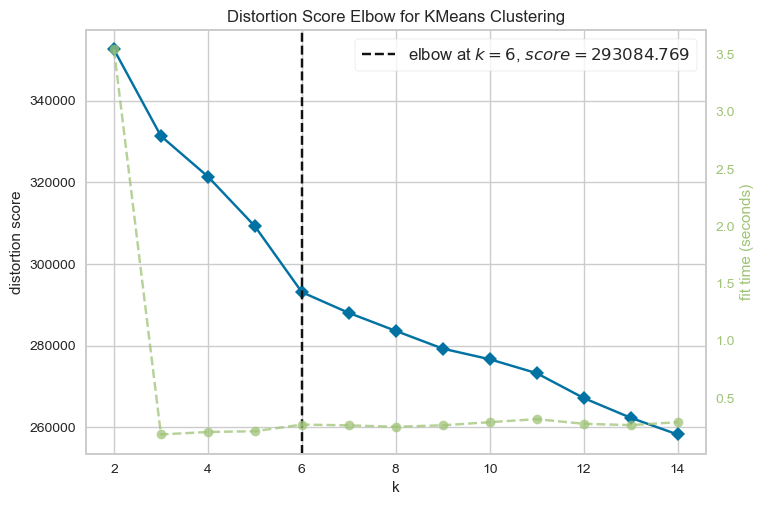

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [14]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Modelo base de KMeans (sin especificar k todavía)
model = KMeans(random_state=42)

# Rango de k a evaluar (incluye valores del 2 al 10)
k = (2, 15)

# Crear el visualizador del método del codo
visualizer = KElbowVisualizer(
    model, 
    k=k, 
    timings=True    #muestra tiempo de entrenamiento
)

# Ajustar el visualizador a los datos
visualizer.fit(df_clustering_final)

# Mostrar la gráfica final
visualizer.show()


### 1º Modelo: K-means

In [15]:
#------------------------------------    Busqueda de k
# Probamos distintos k (2 a 10)
k_values = range(2, 15)
inertias = []
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(df_clustering_final)
    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(df_clustering_final, etiquetas))

print(inertias)
print(silhouettes)

[352570.8182402428, 325199.88370142883, 307918.9107345029, 299520.44432299037, 292048.2636352843, 285862.36747895816, 280825.3331828104, 277360.3228557641, 272141.57880135276, 267266.0005308343, 263509.3357875419, 260589.34240097489, 255121.3801141682]
[np.float64(0.09970523232174137), np.float64(0.12728040088843584), np.float64(0.11294306659293489), np.float64(0.11120940163406696), np.float64(0.1137555875960233), np.float64(0.0993748687614202), np.float64(0.100253158149856), np.float64(0.0921530363738216), np.float64(0.08513947649065694), np.float64(0.09838034018888567), np.float64(0.08802262207139012), np.float64(0.09371762212732426), np.float64(0.09543941328652454)]


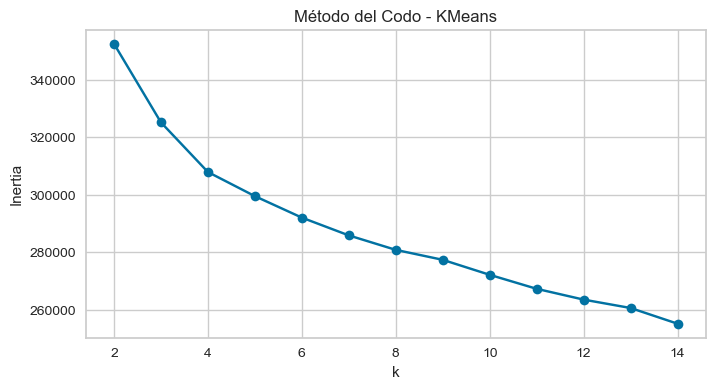

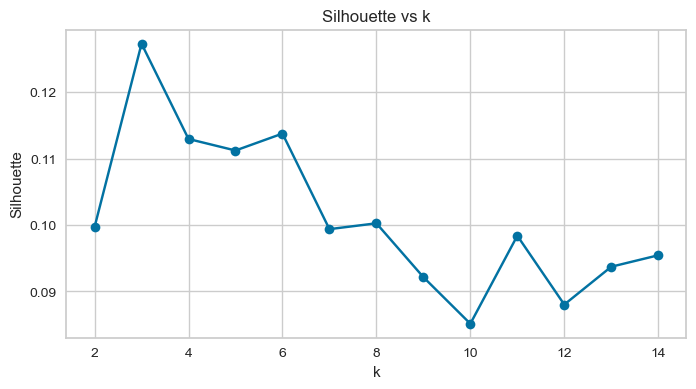

In [16]:
#------------------------------------    Graficos

# Método del codo
plt.figure(figsize=(8,4))
plt.plot(k_values, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Método del Codo - KMeans")
plt.show()

# Índice de Silueta
plt.figure(figsize=(8,4))
plt.plot(k_values, silhouettes, '-o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# Función para evaluar clustering
def evaluar_clustering(X, labels):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan

    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    return sil, db, ch

# Valores de k a probar
k_values_prueba = [3, 4, 5]
X = df_clustering_final.values

resultados_clusters = {}

for k in k_values_prueba:

    print(f"\n--- k = {k} ---")

    # Ajustar KMeans
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(X)

    # SANITY CHECK
    print("Clusters únicos:", np.unique(etiquetas))

    # Centroides
    centroides = pd.DataFrame(
        modelo.cluster_centers_,
        columns=df_clustering_final.columns
    )
    centroides["cluster"] = range(k)

    # Instancias por cluster
    instancias_por_cluster = np.bincount(etiquetas)

    # Evaluar clustering
    sil, db, ch = evaluar_clustering(X, etiquetas)

    # Guardar resultados
    resultados_clusters[k] = {
        "modelo": modelo,
        "etiquetas": etiquetas,
        "centroides": centroides,
        "instancias_por_cluster": instancias_por_cluster,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch
    }

    # Imprimir resultados
    print("Instancias por cluster:", instancias_por_cluster)
    
    # Tabla de métricas
    tabla_metricas = pd.DataFrame({
        "Métrica": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
        "Valor": [sil, db, ch]
    })
    
    print("\nMétricas de validación interna:")
    print(tabla_metricas)



--- k = 3 ---
Clusters únicos: [0 1 2]
Instancias por cluster: [20060 19287 12360]

Métricas de validación interna:
             Métrica        Valor
0         Silhouette     0.127280
1     Davies-Bouldin     2.623028
2  Calinski-Harabasz  5436.867216

--- k = 4 ---
Clusters únicos: [0 1 2 3]
Instancias por cluster: [19287 10103  9957 12360]

Métricas de validación interna:
             Métrica        Valor
0         Silhouette     0.112943
1     Davies-Bouldin     2.549303
2  Calinski-Harabasz  4795.144405

--- k = 5 ---
Clusters únicos: [0 1 2 3 4]
Instancias por cluster: [ 9957 12360  5175 10103 14112]

Métricas de validación interna:
             Métrica        Valor
0         Silhouette     0.111209
1     Davies-Bouldin     2.850999
2  Calinski-Harabasz  4059.556400


In [ ]:
from scipy.spatial.distance import cdist
import pandas as pd
import numpy as np

# Convertir todo a float
X_numeric = df_clustering_final.values.astype(float)

k_values = [3, 4, 5]

for k in k_values:
    resultado = resultados_clusters[k]
    etiquetas = resultado["etiquetas"]
    centroides = resultado["centroides"].drop(columns="cluster").values.astype(float)
    
    print(f"\n--- k = {k} ---")
    
    # Distancia intra-cluster promedio por cluster
    dist_intra = np.array([cdist(X_numeric[etiquetas == i], [centroides[i]]).mean() 
                           for i in range(k)])
    
    # Distancia mínima inter-cluster
    dist_inter = cdist(centroides, centroides)
    np.fill_diagonal(dist_inter, np.nan)
    min_dist_inter = np.nanmin(dist_inter)
    
    # Tabla de distancias
    tabla_distancias = pd.DataFrame({
        "Cluster": range(k),
        "Distancia_intra": np.round(dist_intra, 4),
        "Distancia_min_inter (Minima)": round(min_dist_inter, 4)
    })
    
    # Tabla de centroides
    tabla_centroides = pd.DataFrame(centroides, columns=df_clustering_final.columns)
    
    # Imprimir resultados
    print("\nDistancias intra e inter por cluster:")
    print(tabla_distancias)
    print("Centroides por cluster (resumen):")
    print(pd.DataFrame(centroides, columns=df_clustering_final.columns).iloc[:2, :2])
    print("--------------------------------------------------------------------------------------------------------------------------------------")




--- k = 3 ---

Distancias intra e inter por cluster:
   Cluster  Distancia_intra  Distancia_min_inter
0        0           2.3960               1.9062
1        1           2.6725               1.9062
2        2           2.3705               1.9062
Centroides por cluster (resumen):
   lead_time  lenght_of_stay
0   0.042347        0.024421
1   0.037864        0.030085

--- k = 4 ---

Distancias intra e inter por cluster:
   Cluster  Distancia_intra  Distancia_min_inter
0        0           2.6725               1.8564
1        1           2.2641               1.8564
2        2           2.1473               1.8564
3        3           2.3705               1.8564
Centroides por cluster (resumen):
   lead_time  lenght_of_stay
0   0.037864        0.030085
1   0.053220        0.024477

--- k = 5 ---

Distancias intra e inter por cluster:
   Cluster  Distancia_intra  Distancia_min_inter
0        0           2.1473               1.4898
1        1           2.3705               1.4898
2       


=== Silhouette analysis para k = 3 ===
Silhouette promedio: 0.1273


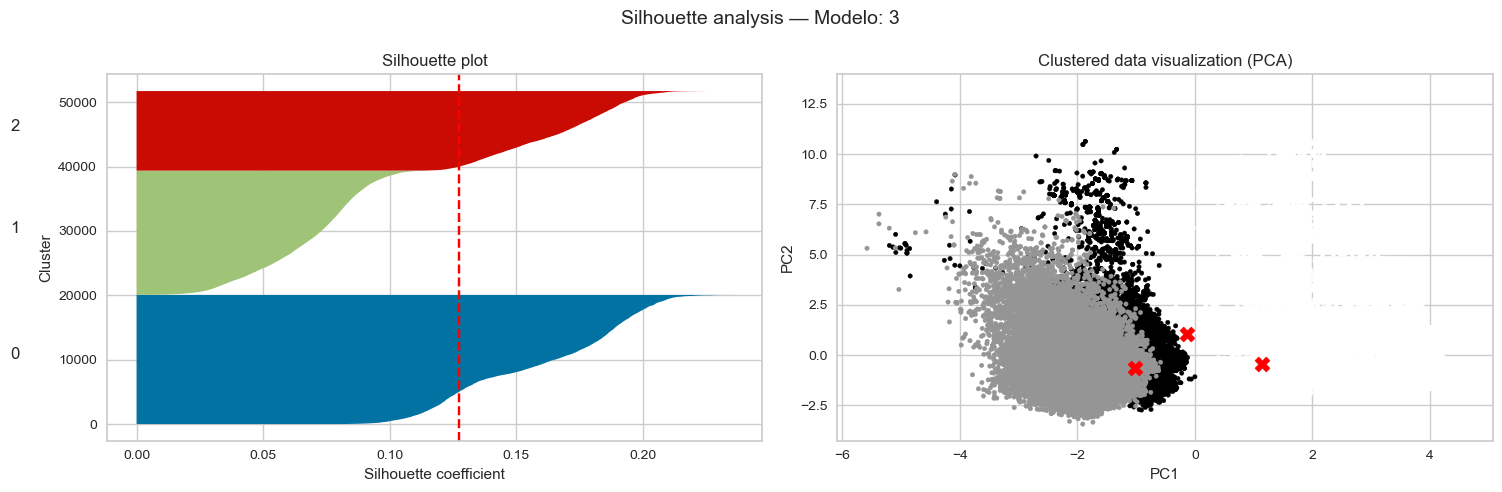


=== Silhouette analysis para k = 4 ===
Silhouette promedio: 0.1129


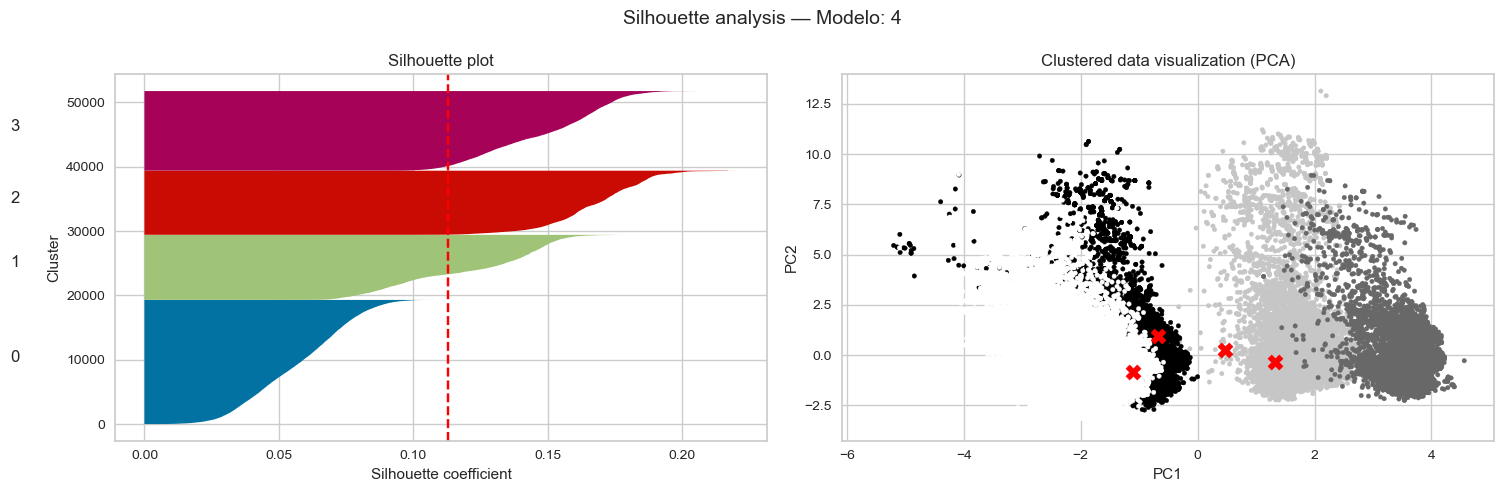


=== Silhouette analysis para k = 5 ===
Silhouette promedio: 0.1112


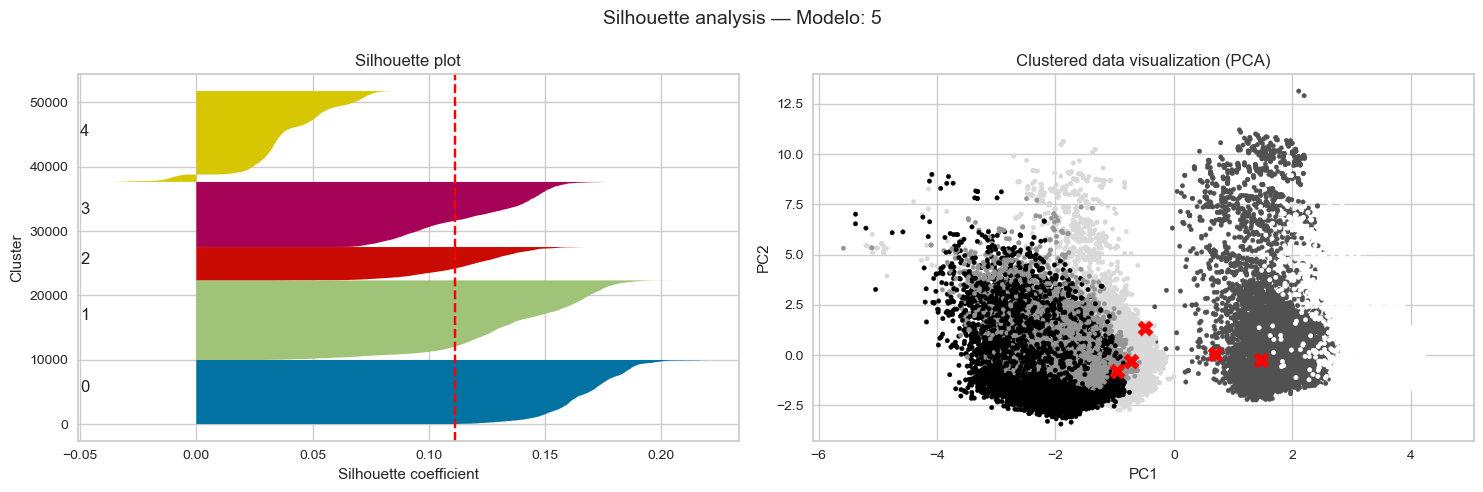

In [27]:
# VISUALIZAR SILHOUTTE PARA CADA K:
from sklearn.metrics import silhouette_samples

k_values_prueba = [3, 4, 5]

for k in k_values_prueba:

    print(f"\n=== Silhouette analysis para k = {k} ===")

    # Entrenar KMeans
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_clustering_final)

    # Métricas Silhouette
    silhouette_avg = silhouette_score(df_clustering_final, labels)
    sample_silhouette_values = silhouette_samples(df_clustering_final, labels)

    print(f"Silhouette promedio: {silhouette_avg:.4f}")

    # Crear figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Silhouette analysis — Modelo: {k}", fontsize=14)

    # ===== SILHOUETTE PLOT =====
    y_lower = 10
    for i in range(k):
        ith_cluster_values = sample_silhouette_values[labels == i]
        ith_cluster_values.sort()

        size_cluster = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_values
        )

        ax1.text(-0.05, y_lower + size_cluster / 2, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster")
    ax1.set_title("Silhouette plot")

    # ===== SCATTER (PCA) =====
    ax2.scatter(
        X_pca_2d[:, 0],
        X_pca_2d[:, 1],
        c=labels,
        s=10
    )

    centers_pca = PCA(n_components=2).fit_transform(kmeans.cluster_centers_)
    ax2.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        c="red",
        s=120,
        marker="X"
    )

    ax2.set_title("Clustered data visualization (PCA)")
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")

    plt.tight_layout()
    plt.show()


In [31]:
# Crear tabla final con todas las métricas y distancias usando resultados_clusters
filas = []

for k, res in resultados_clusters.items():
    # Distancias intra e inter
    etiquetas = res['etiquetas']
    centroides = res['centroides'].drop(columns='cluster').values.astype(float)
    
    # Distancia intra-cluster promedio
    dist_intra = np.mean([cdist(X_numeric[etiquetas == i], [centroides[i]]).mean() for i in range(k)])
    
    # Distancia mínima inter-cluster
    dist_inter = cdist(centroides, centroides)
    np.fill_diagonal(dist_inter, np.nan)
    min_dist_inter = np.nanmin(dist_inter)
    
    filas.append({
        'k': k,
        'Silhouette': res['silhouette'],
        'Davies-Bouldin': res['davies_bouldin'],
        'Calinski-Harabasz': res['calinski_harabasz'],
        'Distancia_intra_promedio': dist_intra,
        'Distancia_min_inter': min_dist_inter
    })

# Convertir a DataFrame y redondear a 4 decimales
tabla_comparativa = pd.DataFrame(filas).sort_values('k').reset_index(drop=True).round(4)

# Mostrar tabla ordenada
print("\n=== Comparación de métricas y distancias por k ===")
display(tabla_comparativa)





=== Comparación de métricas y distancias por k ===


,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,Distancia_intra_promedio,Distancia_min_inter
0,3,0.1273,2.6230,5436.8672,2.4797,1.9062
1,4,0.1129,2.5493,4795.1444,2.3636,1.8564
2,5,0.1112,2.8510,4059.5564,2.3718,1.4898


ELEGIR MEJOR VALOR DE K

In [32]:
# Elegir el mejor k según combinación de Silhouette y distancias
# Silhouette alto, intra baja, inter alta
tabla_comparativa['score'] = (
    (tabla_comparativa['Silhouette'] / tabla_comparativa['Silhouette'].max()) - 
    (tabla_comparativa['Distancia_intra_promedio'] / tabla_comparativa['Distancia_intra_promedio'].max()) +
    (tabla_comparativa['Distancia_min_inter'] / tabla_comparativa['Distancia_min_inter'].max())
)

k_mejor = int(tabla_comparativa.loc[tabla_comparativa['score'].idxmax(), 'k'])
print(f"Mejor k según Silhouette y distancias: {k_mejor}")

# Resumen 2x2 de los centroides del modelo final
centroides_final = resultados_clusters[k_mejor]['centroides']
print("\nCentroides del modelo final (resumen 2x2):")
display(centroides_final.iloc[:2, :2].round(4))


Mejor k según Silhouette y distancias: 3

Centroides del modelo final (resumen 2x2):


,lead_time,lenght_of_stay
0,0.0423,0.0244
1,0.0379,0.0301
